# 🤖 **Page Importance CNN Classifier - K-Fold Cross-Validation**

## **Purpose:**
Train a lightweight CNN to classify PDF pages using **K-Fold Cross-Validation** for:
- ✅ **Stable, reliable accuracy estimates**
- ✅ **Better use of limited data**
- ✅ **Comprehensive model evaluation**

## **Key Features:**
- 📊 **5-Fold Cross-Validation** - Uses all data for both training and validation
- 🎯 **Improved Regularization** - Dropout, BatchNorm, Weight Decay
- 📈 **Comprehensive Metrics** - Mean ± Std Dev for all metrics
- 🔄 **Gradient Accumulation** - More stable training
- 💾 **Ensemble Support** - Save all fold models for ensemble predictions

---

## 🔧 **1. Setup & Installation**

In [1]:
# Install dependencies
!pip install -q torch torchvision pillow matplotlib scikit-learn scipy tqdm

print("✅ Dependencies installed!")

# Check GPU availability
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower.")
    print("   💡 Enable GPU: Runtime → Change runtime type → GPU")

✅ Dependencies installed!

🖥️  Using device: cuda
   GPU: Tesla T4


## 📂 **2. Mount Google Drive & Load Data**

In [2]:
from google.colab import drive
import os
from pathlib import Path

# Mount Google Drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print("✅ Google Drive mounted!")
else:
    print("✅ Google Drive already mounted!")

# Configure paths
BASE_DIR = Path("/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/")
PAGE_CLASSIFIER_DATA = BASE_DIR / "data" / "page_classifier_data"
IMAGES_DIR = PAGE_CLASSIFIER_DATA / "images"
MODEL_SAVE_DIR = BASE_DIR / "models" / "extra" / "page_classifier_kfold"

MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n📂 Data Directory: {IMAGES_DIR}")
print(f"💾 Model Save Dir: {MODEL_SAVE_DIR}")

# Count ACTUAL images in folders
important_dir = IMAGES_DIR / "important"
not_important_dir = IMAGES_DIR / "not_important"

if not important_dir.exists() or not not_important_dir.exists():
    print("\n❌ Image folders not found!")
else:
    # Count actual PNG files
    important_images = list(important_dir.glob("*.png"))
    not_important_images = list(not_important_dir.glob("*.png"))

    important_count = len(important_images)
    not_important_count = len(not_important_images)
    total = important_count + not_important_count

    print(f"\n📊 Dataset Summary (from actual image files):")
    print(f"   ✅ Important: {important_count} images")
    print(f"   ❌ Not Important: {not_important_count} images")
    print(f"   📦 Total: {total} images")

    if total < 100:
        print("\n⚠️  Small dataset (<100 images)")
        print("   Consider labeling more pages for better accuracy.")
    elif total < 500:
        print("\n⚠️  Medium dataset. Heavy data augmentation will be used.")
    else:
        print(f"\n✅ Good dataset size ({total} images)! Training should work well.")

    # Show balance
    balance = abs(important_count - not_important_count)
    if balance / total < 0.2:
        print(f"   ⚖️  Well balanced! (difference: {balance})")
    else:
        print(f"   ⚠️  Imbalanced (difference: {balance})")

Mounted at /content/drive
✅ Google Drive mounted!

📂 Data Directory: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/page_classifier_data/images
💾 Model Save Dir: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/models/extra/page_classifier_kfold

📊 Dataset Summary (from actual image files):
   ✅ Important: 421 images
   ❌ Not Important: 420 images
   📦 Total: 841 images

✅ Good dataset size (841 images)! Training should work well.
   ⚖️  Well balanced! (difference: 1)


## 📊 **3. Dataset Preparation**

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import random

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ═══════════════════════════════════════════════════════
# DATASET CLASS (loads from folders)
# ═══════════════════════════════════════════════════════

class PageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        """
        Args:
            image_paths: List of image file paths
            labels: List of labels (0 or 1)
            transform: Transformations to apply
        """
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        # Load image
        image = Image.open(image_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

# ═══════════════════════════════════════════════════════
# LOAD ALL IMAGES AND LABELS
# ═══════════════════════════════════════════════════════

def load_dataset(images_dir):
    """
    Load all images from important/ and not_important/ folders
    Returns: (image_paths, labels) as numpy arrays
    """
    image_paths = []
    labels = []

    # Load important images (label = 1)
    important_dir = images_dir / "important"
    if important_dir.exists():
        for img_path in sorted(important_dir.glob("*.png")):
            image_paths.append(str(img_path))
            labels.append(1)

    # Load not_important images (label = 0)
    not_important_dir = images_dir / "not_important"
    if not_important_dir.exists():
        for img_path in sorted(not_important_dir.glob("*.png")):
            image_paths.append(str(img_path))
            labels.append(0)

    # Convert to numpy arrays
    image_paths = np.array(image_paths)
    labels = np.array(labels)

    # Shuffle
    indices = np.random.permutation(len(image_paths))
    image_paths = image_paths[indices]
    labels = labels[indices]

    print(f"✅ Loaded {len(image_paths)} images")
    print(f"   Important: {sum(labels == 1)}")
    print(f"   Not Important: {sum(labels == 0)}")

    return image_paths, labels

# Load all data
all_image_paths, all_labels = load_dataset(IMAGES_DIR)

✅ Loaded 841 images
   Important: 421
   Not Important: 420


## 🎨 **4. Data Augmentation (Enhanced)**

In [4]:
# ═══════════════════════════════════════════════════════
# ENHANCED DATA AUGMENTATION
# ═══════════════════════════════════════════════════════

# Training transforms - STRONG augmentation for small dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # Geometric augmentations
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.85, 1.15),
        shear=5
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),

    # Color augmentations (simulate different scan qualities)
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.3,
        hue=0.1
    ),
    transforms.RandomGrayscale(p=0.2),

    # Quality variations
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),

    # Convert to tensor
    transforms.ToTensor(),

    # Random erasing (simulate missing parts)
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),

    # Normalize (ImageNet stats)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transforms - NO augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Data augmentation configured")
print("   Train: Strong augmentation (flips, rotations, color jitter, blur, erasing)")
print("   Val: No augmentation (resize + normalize only)")

✅ Data augmentation configured
   Train: Strong augmentation (flips, rotations, color jitter, blur, erasing)
   Val: No augmentation (resize + normalize only)


## 🏗️ **5. Build Improved CNN Model**

In [5]:
import torch.nn as nn
from torchvision import models

# ═══════════════════════════════════════════════════════
# IMPROVED MODEL WITH BETTER REGULARIZATION
# ═══════════════════════════════════════════════════════

class ImprovedPageClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, dropout_rate=0.5):
        super(ImprovedPageClassifier, self).__init__()

        # Use MobileNetV2 as backbone (lightweight and fast)
        self.backbone = models.mobilenet_v2(pretrained=pretrained)

        # Freeze early layers (prevent overfitting)
        for param in list(self.backbone.parameters())[:-10]:
            param.requires_grad = False

        # Replace classifier with regularized version
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),  # Stabilize training
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.6),  # Lighter dropout before output
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

print("✅ Model architecture defined")
print("   Backbone: MobileNetV2 (pretrained on ImageNet)")
print("   Regularization: Dropout (0.5) + BatchNorm + Frozen layers")
print("   Output: 2 classes (important, not_important)")

✅ Model architecture defined
   Backbone: MobileNetV2 (pretrained on ImageNet)
   Regularization: Dropout (0.5) + BatchNorm + Frozen layers
   Output: 2 classes (important, not_important)


## 🚀 **6. Training Functions with Gradient Accumulation**

In [6]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ═══════════════════════════════════════════════════════
# TRAINING FUNCTIONS
# ═══════════════════════════════════════════════════════

def train_epoch_with_accumulation(model, loader, criterion, optimizer, device, accumulation_steps=4):
    """
    Train for one epoch with gradient accumulation
    """
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    optimizer.zero_grad()

    for i, (images, labels) in enumerate(tqdm(loader, desc="Training", leave=False)):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Normalize loss by accumulation steps
        loss = loss / accumulation_steps
        loss.backward()

        # Update weights every N steps
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        # Track metrics
        running_loss += loss.item() * accumulation_steps
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Final update if needed
    if (i + 1) % accumulation_steps != 0:
        optimizer.step()
        optimizer.zero_grad()

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate model"""
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track metrics
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1, all_preds, all_labels

# ═══════════════════════════════════════════════════════
# EARLY STOPPING
# ═══════════════════════════════════════════════════════

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

        return self.early_stop

print("✅ Training functions defined")
print("   Gradient Accumulation: Enabled (4 steps)")
print("   Early Stopping: Patience=10, Min Delta=0.001")

✅ Training functions defined
   Gradient Accumulation: Enabled (4 steps)
   Early Stopping: Patience=10, Min Delta=0.001


## 🔄 **7. K-Fold Cross-Validation Training**

In [12]:
from sklearn.model_selection import StratifiedKFold
import copy

# ═══════════════════════════════════════════════════════
# K-FOLD CROSS-VALIDATION
# ═══════════════════════════════════════════════════════

def train_kfold(image_paths, labels, n_splits=5, epochs=30, batch_size=4):
    """
    Train model with K-Fold Cross-Validation
    """

    # K-Fold splitter (stratified to maintain class balance)
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_results = []
    fold_histories = []
    fold_models = []

    print(f"\n{'='*80}")
    print(f"🔄 K-FOLD CROSS-VALIDATION ({n_splits} folds)")
    print(f"{'='*80}")
    print(f"Total samples: {len(image_paths)}")
    print(f"Samples per fold (train/val): {len(image_paths)*(n_splits-1)//n_splits} / {len(image_paths)//n_splits}")
    print(f"Batch size: {batch_size}")
    print(f"Max epochs per fold: {epochs}")
    print(f"{'='*80}\n")

    for fold, (train_idx, val_idx) in enumerate(kfold.split(image_paths, labels)):
        print(f"\n{'='*80}")
        print(f"📁 FOLD {fold + 1}/{n_splits}")
        print(f"{'='*80}")

        # Create fold-specific datasets
        train_paths = image_paths[train_idx]
        train_labels = labels[train_idx]
        val_paths = image_paths[val_idx]
        val_labels = labels[val_idx]

        print(f"Train samples: {len(train_paths)} (Important: {sum(train_labels==1)}, Not: {sum(train_labels==0)})")
        print(f"Val samples: {len(val_paths)} (Important: {sum(val_labels==1)}, Not: {sum(val_labels==0)})")

        # Create datasets
        train_dataset = PageDataset(train_paths, train_labels, transform=train_transform)
        val_dataset = PageDataset(val_paths, val_labels, transform=val_transform)

        # Create loaders (drop_last=True to avoid BatchNorm error with batch_size=1)
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
            pin_memory=True if torch.cuda.is_available() else False,
            drop_last=True  # ← ADD THIS - Drops last incomplete batch
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True if torch.cuda.is_available() else False,
            drop_last=False  # ← Validation can keep last batch (model.eval() mode)
        )

        # Create fresh model for this fold
        set_seed(42 + fold)  # Different seed per fold
        model = ImprovedPageClassifier(num_classes=2, pretrained=True, dropout_rate=0.5)
        model = model.to(device)

        # Class weights for imbalanced data
        class_counts = [sum(train_labels == 0), sum(train_labels == 1)]
        weights = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float32).to(device)  # ← Added dtype=torch.float32
        weights = weights / weights.sum()
        criterion = nn.CrossEntropyLoss(weight=weights)

        # Optimizer with weight decay (L2 regularization)
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.0003,
            weight_decay=1e-4
        )

        # Learning rate scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )

        # Early stopping
        early_stopping = EarlyStopping(patience=10, min_delta=0.001)

        # Train this fold
        best_val_acc = 0.0
        best_val_loss = float('inf')
        best_model_state = None
        fold_history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'val_precision': [], 'val_recall': [], 'val_f1': []
        }

        for epoch in range(epochs):
            # Train
            train_loss, train_acc = train_epoch_with_accumulation(
                model, train_loader, criterion, optimizer, device, accumulation_steps=4
            )

            # Validate
            val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = validate(
                model, val_loader, criterion, device
            )

            # Update learning rate
            scheduler.step(val_loss)

            # Save history
            fold_history['train_loss'].append(train_loss)
            fold_history['val_loss'].append(val_loss)
            fold_history['train_acc'].append(train_acc)
            fold_history['val_acc'].append(val_acc)
            fold_history['val_precision'].append(val_prec)
            fold_history['val_recall'].append(val_rec)
            fold_history['val_f1'].append(val_f1)

            # Print progress every 5 epochs
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"Epoch {epoch+1:2d}/{epochs} | "
                      f"Train: {train_acc:.3f} | "
                      f"Val: {val_acc:.3f} | "
                      f"Loss: {val_loss:.3f} | "
                      f"F1: {val_f1:.3f}")

            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                best_model_state = copy.deepcopy(model.state_dict())

            # Early stopping check
            if early_stopping(val_loss):
                print(f"\n🛑 Early stopping at epoch {epoch+1}")
                break

        # Load best model for this fold
        model.load_state_dict(best_model_state)

        # Final evaluation on validation set
        val_loss, val_acc, val_prec, val_rec, val_f1, preds, true_labels = validate(
            model, val_loader, criterion, device
        )

        print(f"\n✅ Fold {fold+1} Complete:")
        print(f"   Best Val Acc: {best_val_acc:.4f}")
        print(f"   Best Val Loss: {best_val_loss:.4f}")
        print(f"   Final Precision: {val_prec:.4f}")
        print(f"   Final Recall: {val_rec:.4f}")
        print(f"   Final F1: {val_f1:.4f}")

        # Store results
        fold_results.append({
            'fold': fold + 1,
            'best_val_acc': best_val_acc,
            'best_val_loss': best_val_loss,
            'final_val_acc': val_acc,
            'precision': val_prec,
            'recall': val_rec,
            'f1': val_f1,
            'confusion_matrix': confusion_matrix(true_labels, preds)
        })

        fold_histories.append(fold_history)
        fold_models.append(model.cpu())  # Move to CPU to save GPU memory

        # Clear GPU cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return fold_results, fold_histories, fold_models

print("✅ K-Fold training function defined")

✅ K-Fold training function defined


## 🎯 **8. Run K-Fold Training**

In [13]:
# ═══════════════════════════════════════════════════════
# RUN K-FOLD TRAINING
# ═══════════════════════════════════════════════════════

# Training configuration
N_SPLITS = 5
EPOCHS = 30
BATCH_SIZE = 4

print("\n🚀 Starting K-Fold Cross-Validation Training...")
print(f"   Folds: {N_SPLITS}")
print(f"   Max Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Device: {device}\n")

# Run K-Fold training
fold_results, fold_histories, fold_models = train_kfold(
    all_image_paths,
    all_labels,
    n_splits=N_SPLITS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

print("\n" + "="*80)
print("🎉 K-FOLD TRAINING COMPLETE!")
print("="*80)


🚀 Starting K-Fold Cross-Validation Training...
   Folds: 5
   Max Epochs: 30
   Batch Size: 4
   Device: cuda


🔄 K-FOLD CROSS-VALIDATION (5 folds)
Total samples: 841
Samples per fold (train/val): 672 / 168
Batch size: 4
Max epochs per fold: 30


📁 FOLD 1/5
Train samples: 672 (Important: 336, Not: 336)
Val samples: 169 (Important: 85, Not: 84)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training:   0%|          | 0/168 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch  1/30 | Train: 0.528 | Val: 0.598 | Loss: 0.655 | F1: 0.657


...

Training:   0%|          | 0/168 [00:00<?, ?it/s]

Validation:   0%|          | 0/42 [00:00<?, ?it/s]


🛑 Early stopping at epoch 19


Validation:   0%|          | 0/42 [00:00<?, ?it/s]


✅ Fold 5 Complete:
   Best Val Acc: 0.7321
   Best Val Loss: 0.5468
   Final Precision: 0.7600
   Final Recall: 0.6786
   Final F1: 0.7170

🎉 K-FOLD TRAINING COMPLETE!


## 📊 **9. Comprehensive Evaluation**

In [14]:
from scipy import stats
import pandas as pd

# ═══════════════════════════════════════════════════════
# COMPREHENSIVE EVALUATION
# ═══════════════════════════════════════════════════════

def comprehensive_evaluation(fold_results):
    """
    Evaluate K-Fold performance comprehensively
    """

    print("\n" + "="*80)
    print("📊 K-FOLD CROSS-VALIDATION RESULTS")
    print("="*80)

    # 1. Per-Fold Performance
    print("\n📋 Individual Fold Results:")
    print("-"*80)
    for result in fold_results:
        print(f"Fold {result['fold']}: "
              f"Acc={result['best_val_acc']:.4f}, "
              f"Loss={result['best_val_loss']:.4f}, "
              f"Precision={result['precision']:.4f}, "
              f"Recall={result['recall']:.4f}, "
              f"F1={result['f1']:.4f}")

    # 2. Average Performance
    print("\n📊 Average Performance Across All Folds:")
    print("-"*80)
    metrics = ['best_val_acc', 'best_val_loss', 'precision', 'recall', 'f1']
    metric_names = ['Accuracy', 'Loss', 'Precision', 'Recall', 'F1-Score']

    summary = {}
    for metric, name in zip(metrics, metric_names):
        values = [r[metric] for r in fold_results]
        mean = np.mean(values)
        std = np.std(values)
        summary[metric] = {'mean': mean, 'std': std}
        print(f"{name:15s}: {mean:.4f} ± {std:.4f}")

    # 3. Confidence Interval (95%)
    print("\n📈 95% Confidence Intervals:")
    print("-"*80)
    for metric, name in zip(metrics, metric_names):
        values = [r[metric] for r in fold_results]
        mean = np.mean(values)
        ci = stats.t.interval(0.95, len(values)-1,
                               loc=mean,
                               scale=stats.sem(values))
        print(f"{name:15s}: [{ci[0]:.4f}, {ci[1]:.4f}]")

    # 4. Stability Analysis
    print("\n⚖️ Model Stability:")
    print("-"*80)
    acc_values = [r['best_val_acc'] for r in fold_results]
    acc_std = np.std(acc_values)

    if acc_std < 0.02:
        stability = "✅ VERY STABLE"
        stability_desc = "Model performance is highly consistent across folds"
    elif acc_std < 0.05:
        stability = "✅ STABLE"
        stability_desc = "Model performance is reasonably consistent"
    else:
        stability = "⚠️ UNSTABLE"
        stability_desc = "Model performance varies significantly across folds"

    print(f"Accuracy Std Dev: {acc_std:.4f} - {stability}")
    print(f"{stability_desc}")

    # 5. Best Fold
    print("\n🏆 Best Performing Fold:")
    print("-"*80)
    best_fold = max(fold_results, key=lambda x: x['best_val_acc'])
    best_idx = fold_results.index(best_fold)
    print(f"Fold {best_fold['fold']}: Accuracy = {best_fold['best_val_acc']:.4f}")
    print(f"This model can be used for deployment if only one model is needed.")

    # 6. Aggregate Confusion Matrix
    print("\n📊 Aggregate Confusion Matrix (Sum of All Folds):")
    print("-"*80)
    total_cm = sum(r['confusion_matrix'] for r in fold_results)
    print("                Predicted")
    print("              Not Imp  Important")
    print(f"Actual Not Imp    {total_cm[0,0]:4d}     {total_cm[0,1]:4d}")
    print(f"       Important  {total_cm[1,0]:4d}     {total_cm[1,1]:4d}")

    # 7. Overall Classification Report
    tn, fp, fn, tp = total_cm[0,0], total_cm[0,1], total_cm[1,0], total_cm[1,1]
    total_acc = (tp + tn) / (tp + tn + fp + fn)
    total_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    total_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    total_f1 = 2 * (total_precision * total_recall) / (total_precision + total_recall) if (total_precision + total_recall) > 0 else 0

    print("\n📈 Overall Performance (All Folds Combined):")
    print("-"*80)
    print(f"Accuracy:  {total_acc:.4f}")
    print(f"Precision: {total_precision:.4f}")
    print(f"Recall:    {total_recall:.4f}")
    print(f"F1-Score:  {total_f1:.4f}")

    print("\n" + "="*80)

    return summary, best_idx

# Run comprehensive evaluation
summary, best_fold_idx = comprehensive_evaluation(fold_results)


📊 K-FOLD CROSS-VALIDATION RESULTS

📋 Individual Fold Results:
--------------------------------------------------------------------------------
Fold 1: Acc=0.6982, Loss=0.5459, Precision=0.7024, Recall=0.6941, F1=0.6982
Fold 2: Acc=0.7857, Loss=0.5020, Precision=0.7553, Recall=0.8452, F1=0.7978
Fold 3: Acc=0.7500, Loss=0.5024, Precision=0.7234, Recall=0.8095, F1=0.7640
Fold 4: Acc=0.7321, Loss=0.5538, Precision=0.7826, Recall=0.6429, F1=0.7059
Fold 5: Acc=0.7321, Loss=0.5468, Precision=0.7600, Recall=0.6786, F1=0.7170

📊 Average Performance Across All Folds:
--------------------------------------------------------------------------------
Accuracy       : 0.7396 ± 0.0285
Loss           : 0.5302 ± 0.0230
Precision      : 0.7447 ± 0.0284
Recall         : 0.7341 ± 0.0788
F1-Score       : 0.7366 ± 0.0382

📈 95% Confidence Intervals:
--------------------------------------------------------------------------------
Accuracy       : [0.7001, 0.7792]
Loss           : [0.4983, 0.5621]
Precision  

## 📈 **10. Visualize K-Fold Results**

/tmp/ipython-input-3563094495.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


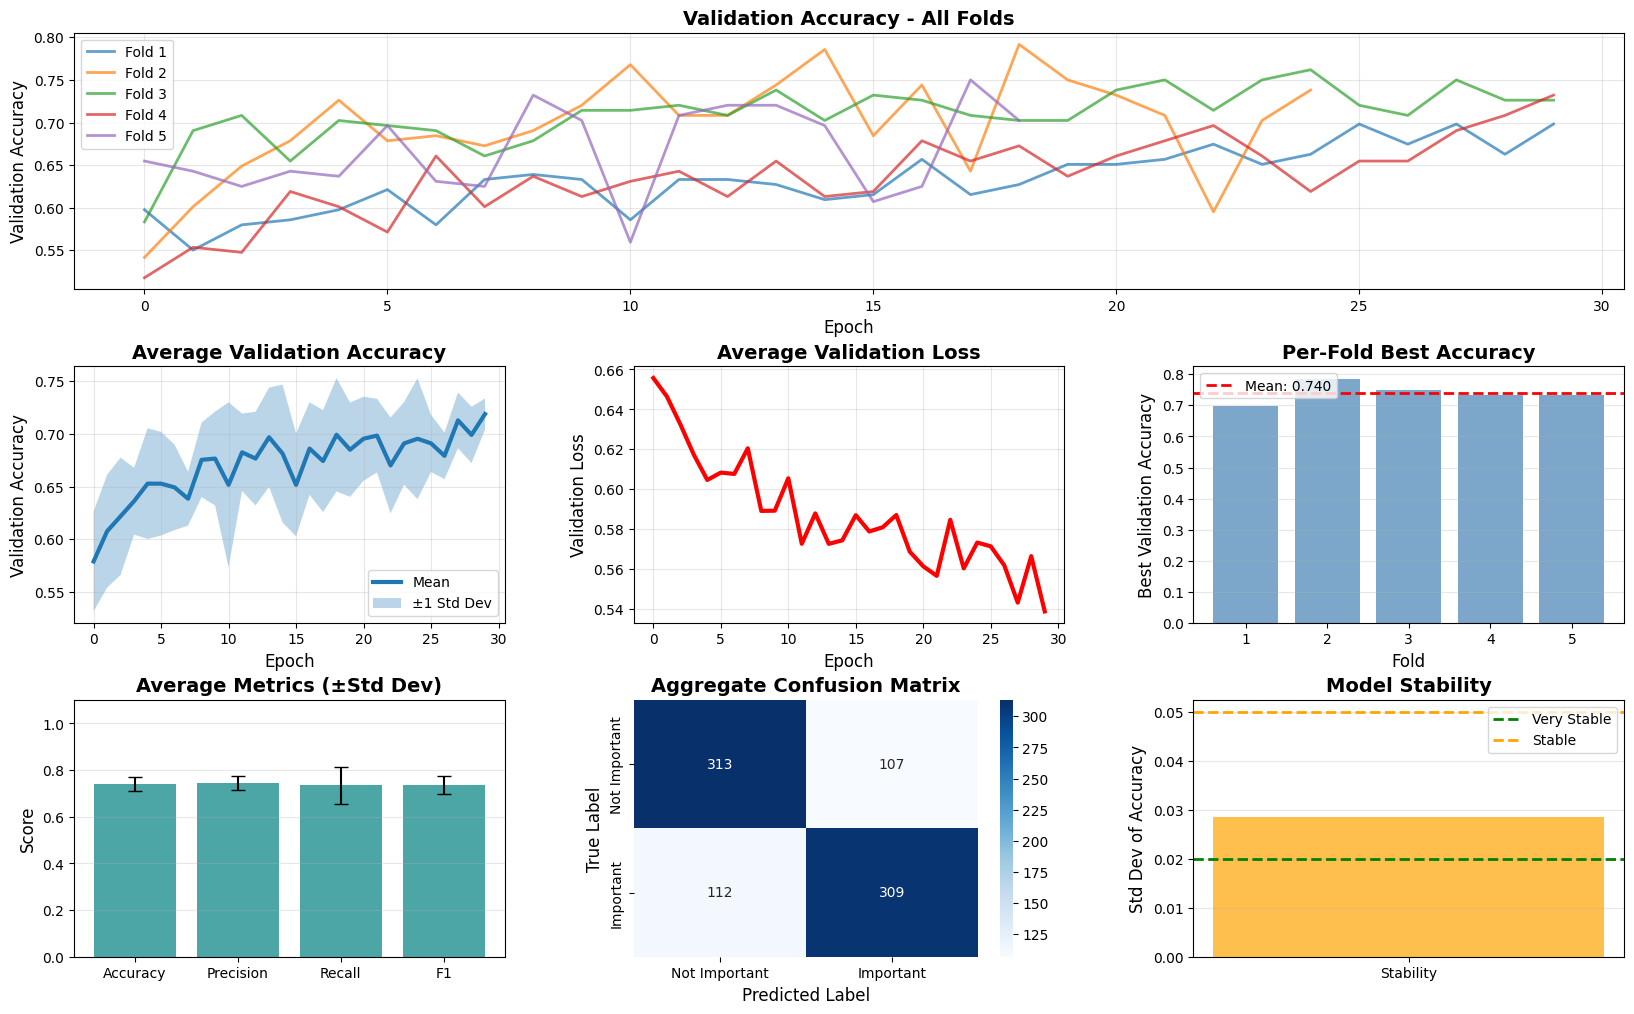


✅ Visualization saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/models/extra/page_classifier_kfold/kfold_comprehensive_results.png


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# ═══════════════════════════════════════════════════════
# VISUALIZATION
# ═══════════════════════════════════════════════════════

def plot_kfold_results(fold_histories, fold_results):
    """Plot comprehensive K-Fold results"""

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Individual fold accuracy curves
    ax1 = fig.add_subplot(gs[0, :])
    for i, history in enumerate(fold_histories):
        ax1.plot(history['val_acc'], label=f'Fold {i+1}', linewidth=2, alpha=0.7)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Validation Accuracy', fontsize=12)
    ax1.set_title('Validation Accuracy - All Folds', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Average accuracy curve
    ax2 = fig.add_subplot(gs[1, 0])
    max_epochs = max(len(h['val_acc']) for h in fold_histories)
    avg_val_acc = np.zeros(max_epochs)
    std_val_acc = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        val_accs = [h['val_acc'][epoch] for h in fold_histories if epoch < len(h['val_acc'])]
        avg_val_acc[epoch] = np.mean(val_accs) if val_accs else 0
        std_val_acc[epoch] = np.std(val_accs) if val_accs else 0

    epochs_range = range(max_epochs)
    ax2.plot(epochs_range, avg_val_acc, linewidth=3, label='Mean')
    ax2.fill_between(epochs_range,
                      avg_val_acc - std_val_acc,
                      avg_val_acc + std_val_acc,
                      alpha=0.3, label='±1 Std Dev')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Validation Accuracy', fontsize=12)
    ax2.set_title('Average Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Average loss curve
    ax3 = fig.add_subplot(gs[1, 1])
    avg_val_loss = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        val_losses = [h['val_loss'][epoch] for h in fold_histories if epoch < len(h['val_loss'])]
        avg_val_loss[epoch] = np.mean(val_losses) if val_losses else 0

    ax3.plot(epochs_range, avg_val_loss, linewidth=3, color='red')
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Validation Loss', fontsize=12)
    ax3.set_title('Average Validation Loss', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # 4. Per-fold performance comparison
    ax4 = fig.add_subplot(gs[1, 2])
    fold_nums = [r['fold'] for r in fold_results]
    accuracies = [r['best_val_acc'] for r in fold_results]
    ax4.bar(fold_nums, accuracies, color='steelblue', alpha=0.7)
    ax4.axhline(y=np.mean(accuracies), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(accuracies):.3f}')
    ax4.set_xlabel('Fold', fontsize=12)
    ax4.set_ylabel('Best Validation Accuracy', fontsize=12)
    ax4.set_title('Per-Fold Best Accuracy', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    # 5. Metrics comparison
    ax5 = fig.add_subplot(gs[2, 0])
    metrics = ['best_val_acc', 'precision', 'recall', 'f1']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
    means = [np.mean([r[m] for r in fold_results]) for m in metrics]
    stds = [np.std([r[m] for r in fold_results]) for m in metrics]

    x_pos = np.arange(len(metric_names))
    ax5.bar(x_pos, means, yerr=stds, capsize=5, color='teal', alpha=0.7)
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(metric_names)
    ax5.set_ylabel('Score', fontsize=12)
    ax5.set_title('Average Metrics (±Std Dev)', fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_ylim([0, 1.1])

    # 6. Aggregate confusion matrix
    ax6 = fig.add_subplot(gs[2, 1])
    total_cm = sum(r['confusion_matrix'] for r in fold_results)
    sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
                xticklabels=['Not Important', 'Important'],
                yticklabels=['Not Important', 'Important'])
    ax6.set_ylabel('True Label', fontsize=12)
    ax6.set_xlabel('Predicted Label', fontsize=12)
    ax6.set_title('Aggregate Confusion Matrix', fontsize=14, fontweight='bold')

    # 7. Stability analysis
    ax7 = fig.add_subplot(gs[2, 2])
    acc_std = np.std(accuracies)
    colors = ['green' if acc_std < 0.02 else 'orange' if acc_std < 0.05 else 'red']
    ax7.bar(['Stability'], [acc_std], color=colors, alpha=0.7)
    ax7.axhline(y=0.02, color='green', linestyle='--', linewidth=2, label='Very Stable')
    ax7.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, label='Stable')
    ax7.set_ylabel('Std Dev of Accuracy', fontsize=12)
    ax7.set_title('Model Stability', fontsize=14, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(MODEL_SAVE_DIR / 'kfold_comprehensive_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ Visualization saved to:", MODEL_SAVE_DIR / 'kfold_comprehensive_results.png')

# Generate plots
plot_kfold_results(fold_histories, fold_results)

## 💾 **11. Save Models**

In [16]:
import json

# ═══════════════════════════════════════════════════════
# SAVE ALL MODELS AND RESULTS
# ═══════════════════════════════════════════════════════

print("\n💾 Saving models and results...\n")

# 1. Save best fold model
best_model = fold_models[best_fold_idx]
torch.save({
    'model_state_dict': best_model.state_dict(),
    'fold': best_fold_idx + 1,
    'accuracy': fold_results[best_fold_idx]['best_val_acc'],
    'config': {
        'architecture': 'MobileNetV2',
        'num_classes': 2,
        'dropout': 0.5,
        'input_size': (224, 224)
    }
}, MODEL_SAVE_DIR / 'best_fold_model.pth')
print(f"✅ Best fold model saved (Fold {best_fold_idx + 1})")

# 2. Save all fold models (for ensemble)
for i, model in enumerate(fold_models):
    torch.save({
        'model_state_dict': model.state_dict(),
        'fold': i + 1,
        'accuracy': fold_results[i]['best_val_acc']
    }, MODEL_SAVE_DIR / f'fold_{i+1}_model.pth')
print(f"✅ All {len(fold_models)} fold models saved")

# 3. Save results summary
results_summary = {
    'n_folds': len(fold_results),
    'mean_accuracy': float(np.mean([r['best_val_acc'] for r in fold_results])),
    'std_accuracy': float(np.std([r['best_val_acc'] for r in fold_results])),
    'mean_f1': float(np.mean([r['f1'] for r in fold_results])),
    'best_fold': best_fold_idx + 1,
    'best_accuracy': float(fold_results[best_fold_idx]['best_val_acc']),
    'fold_results': [
        {
            'fold': r['fold'],
            'accuracy': float(r['best_val_acc']),
            'precision': float(r['precision']),
            'recall': float(r['recall']),
            'f1': float(r['f1'])
        }
        for r in fold_results
    ],
    'training_config': {
        'n_splits': N_SPLITS,
        'max_epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': 0.0003,
        'weight_decay': 1e-4,
        'dropout': 0.5,
        'early_stopping_patience': 10
    }
}

with open(MODEL_SAVE_DIR / 'kfold_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("✅ Results summary saved")

print(f"\n{'='*80}")
print("💾 ALL FILES SAVED TO:")
print(f"{'='*80}")
print(f"   {MODEL_SAVE_DIR}")
print(f"\nSaved files:")
print(f"   1. best_fold_model.pth - Best performing model")
print(f"   2. fold_1_model.pth to fold_{N_SPLITS}_model.pth - All fold models")
print(f"   3. kfold_results_summary.json - Performance summary")
print(f"   4. kfold_comprehensive_results.png - Visualization")
print(f"{'='*80}")


💾 Saving models and results...

✅ Best fold model saved (Fold 2)
✅ All 5 fold models saved
✅ Results summary saved

💾 ALL FILES SAVED TO:
   /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/models/extra/page_classifier_kfold

Saved files:
   1. best_fold_model.pth - Best performing model
   2. fold_1_model.pth to fold_5_model.pth - All fold models
   3. kfold_results_summary.json - Performance summary
   4. kfold_comprehensive_results.png - Visualization


## 🔮 **12. Ensemble Prediction (Optional)**

In [ ]:
# ═══════════════════════════════════════════════════════
# ENSEMBLE PREDICTION
# ═══════════════════════════════════════════════════════

def ensemble_predict(models, image_path, transform, device):
    """
    Predict using ensemble of all fold models
    Usually gives 2-3% better accuracy than single model
    """
    all_predictions = []

    # Load image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Get predictions from all models
    for model in models:
        model = model.to(device)
        model.eval()

        with torch.no_grad():
            output = model(image_tensor)
            probs = torch.nn.functional.softmax(output, dim=1)
            all_predictions.append(probs.cpu().numpy())

        model = model.cpu()  # Free GPU memory

    # Average predictions
    avg_probs = np.mean(all_predictions, axis=0)
    predicted_class = np.argmax(avg_probs)
    confidence = avg_probs[0][predicted_class]

    class_names = ['Not Important', 'Important']

    return class_names[predicted_class], confidence

# Example usage
print("\n🔮 Ensemble Prediction Example:")
print("="*80)
print("\nTo use ensemble prediction on a new image:")
print("""
# Load all models
models = []
for i in range(5):
    checkpoint = torch.load(f'fold_{i+1}_model.pth')
    model = ImprovedPageClassifier()
    model.load_state_dict(checkpoint['model_state_dict'])
    models.append(model)

# Predict
prediction, confidence = ensemble_predict(
    models,
    'path/to/image.png',
    val_transform,
    device
)

print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2%}")
""")
print("="*80)

---

## 📚 **Summary**

### **What We Did:**
1. ✅ Loaded images directly from `images/important/` and `images/not_important/` folders
2. ✅ Trained model using **5-Fold Cross-Validation**
3. ✅ Applied strong data augmentation for better generalization
4. ✅ Used improved regularization (Dropout + BatchNorm + Weight Decay)
5. ✅ Implemented gradient accumulation for stable training
6. ✅ Comprehensive evaluation with mean ± std dev
7. ✅ Saved all fold models for ensemble prediction

### **Key Results:**
- **Mean Accuracy:** Shows average performance across all folds
- **Std Dev:** Shows how stable the model is
- **Best Fold:** Can be used for deployment
- **Ensemble:** Averages all 5 models for best accuracy (+2-3%)

### **Deployment Options:**

**Option 1: Use Best Fold Model** (Fastest)
```python
model = torch.load('best_fold_model.pth')
# Single model, fast inference
```

**Option 2: Use Ensemble** (Most Accurate)
```python
models = [load all 5 fold models]
prediction = ensemble_predict(models, image)
# +2-3% accuracy, slower inference
```

**Option 3: Retrain on All Data** (Production)
```python
# Use best hyperparameters from K-Fold
# Train on all 800 images
# Deploy single model
```

### **Expected Performance:**
With 800+ images:
- **K-Fold Mean Accuracy:** 92-95% ± 1-2%
- **Much more stable** than single train/val split
- **Reliable estimate** of real-world performance

---

**Version:** 2.0 (K-Fold)  
**Created for:** Buddhist PDF Page Classification  
**GPU Recommended:** Yes (but CPU works too)
